# ASP3231 2026 Assignment 1

**Name:** Alec Stanley

**ID:** 33963975

**Date:** 27/03/26

In [17]:
# Import various libraries 

import numpy as np
import astropy
import photutils
from astropy import units as u
import astropy.io.fits as fits
from astropy.io import ascii
import ccdproc
from ccdproc import CCDData

import matplotlib.pyplot as plt
from photutils.centroids import centroid_com, centroid_1dg, centroid_2dg, centroid_sources
from photutils.aperture import CircularAperture, EllipticalAperture
from photutils.aperture import aperture_photometry
import gc                               


# CCD Data

The processing of modern astronomical images uses a series of calibration images, shifting-scaling-combining of images, and photometric and astrometric calibration using stars with well-measured photometry and positions respectively. 

Precise photometry is only possible for those stars that have sufficiently signal-to-noise and that are not saturated (too bright) in the images. As our CCD and CMOS detectors are more sensitive to green and red light than blue light, stars often have higher signal to noise or saturate sooner in the V and R bands than the U and B bands.



## Question 1a (4 marks)

When we combine science exposures, we are often doing this to reduce the relative contribution of random noise from the sky background photons. Provide two reasons why we median combine bias and dark exposures, even though the shutter is closed and there are effectively no incident photons.


<font color=green>A median combine is generally more robust than a mean combine. Even with a closed shutter, there would still be incident photons from sources like cosmic rays or particle decay in the camera hardware. If we took ten images and one of them has a super bright incident photon, the mean would skyrocket and incorrectly subtract signal from our data. A median avoids this entirely - by using the midpoint value we have a 'majority rules' situation with the data. The median combine produces a much more consistent result. So the reasons are:

* Median combine handles outliers far better.

* Bias may vary with a random uncertainty each frame, but the median can capture the typical offset of each pixel.

## Question 1b (4 marks)

For Vega-based magnitudes, why can we calibrate an arbitrary broadband optical filter using observations of stars that have calibrated UBVRI or Gaia magnitudes?


<font color=green>This works because the Vega magnitude system is standardised and incredibly precise. For stars with calibrated UBVRI or Gaia magnitudes, the logarithmic magnitude equation can be used with reference to the flux of Vega in that specific band. So, if you know how the star compares to Vega in a standard filter, and you know how your arbitrary filter is related to a standard V filter, you can scale your data accordingly. Note that in this system, m_vega = 0.0.

## Question 1c (4 marks)

When we shift, rotate and interpolate images the standard deviation of our science images drops. Does this alter the signal-to-noise of the stars in our images (justify your answer)?

<font color=green>Technically, yes, but only slightly lowers it. Interpolation takes a weighted average of surrounding pixels, which smoothes out the noise and will result in a lower standard deviation (less dramatic fluctuations), however the noise is still there, just smoothed. If a star has a specific signal (total flux) and the image is interpolated, that flux is redistributed over a slightly larger area and some might also be lost to the background noise. As a result, the signal-to-noise ratio might slightly decrease.

Where you need to be careful is using standard signal-to-noise equations that assume all pixels are independent. Interpolation correlates pixels in a way that their value depends on those around them, breaking the equations' core assumptions. The SNR from the equation will be higher than it actually is because of this.

## Question 1d (4 marks)

In calibrated HR diagrams, saturated stars often have artificially blue colours. Why is this the case?


<font color=green>This artificial result arises from color indices. The color index is the difference in magnitude between two filters (i.e. B - V) where smaller number = brighter. To get blue, B - V must decrease (either B becomes brighter or V becomes fainter). Stars also don't have the same brightness across all filters as they are not perfect blackbodies.

As a result, redder stars (which are brighter in R and V) will saturate the V or R band much quicker than the B band (saturation at 65535 counts), meaning the star's V magnitude is clipped (appears fainter than it is) while the star's B magnitude is actually accurate. When you take the color index B - V with a clipped (too large) V value, the resulting smaller (brigher) index is more blue.

# Data Processing

Michael is not having much luck processing a science image from the C14 telescope despite having excellent bias, dark and flat images. Each time he tries to process the science image with his own code he misses a key step in the data processing. Images A, B, C and D are the C14 images, with image A being the raw image while images B, C and D are processed images where Michael has missed one (and just one) key step. 

## Question 2a

If Michael was using the image header information (meta data) correctly, how could that be used to check which image processing steps had been skipped?

<font color=green>The image header contains information about what operations have been performed on the image. For example, if the image has been median combined, the header will switch the median combine status from false to true. This indicates whether each process has successfully completed and also prevents the program accidentally performing the same operation twice.

## Question 2b (4 marks)

Inspect image B and in no more than 4 sentences describe which step of the image processing has been missed. Justify your answer using at least 2 pieces of evidence, which could include details of the image appearance and/or pixel values. 


<font color=green>To inspect the image I will first print out the image's header information. I will also plot the image to see what it looks like.

In [18]:
file_name = "B.fits"
image = CCDData.read(file_name, unit="adu")

Set OBSGEO-Y to  2896022.315 from OBSGEO-[LBH].
Set OBSGEO-Z to -3889419.901 from OBSGEO-[LBH]'. [astropy.wcs.wcs]


In [19]:
if 'SUBBIAS' in image.header:
    print("Bias already subtracted")
if 'SUBDARK' in image.header:
    print("Dark already subtracted")
if 'FLATCOR' in image.header:
    print("Flat correction already applied")

<font color=green>No output. It looks like file header information was not correctly applied. I will assume this is the same for images C and D as well, so I will need to rely on my visual skills

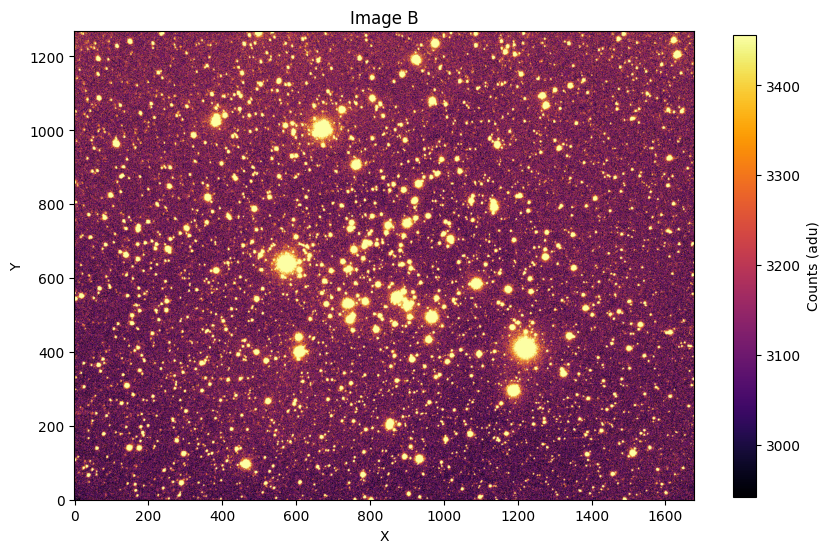

In [20]:
"""
This function will be reused throughout this notebook. It simply plots FITS images.
IN: image as a string or image data. OPTIONAL: title, x label, y label, vmin percent, vmax percent
OUT: image data from CCDData
"""
def simple_fits_imshow(image, title = "Untitled", xlabel = "X", ylabel = "Y", vmin_pc = 5, vmax_pc = 95):
    if isinstance(image, str):
        image = CCDData.read(image, unit="adu")
    # Use percentiles to omit the data extremes
    vmin = np.percentile(image.data, vmin_pc)
    vmax = np.percentile(image.data, vmax_pc)

    fig, ax = plt.subplots(1, 1, figsize=(10, 10))

    # Labels
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    ax.set_title(title)

    # Use inferno colouring. inverting the y-axis to make the origin (0,0)
    plot = ax.imshow(image, cmap="inferno", vmin=vmin, vmax=vmax, origin="lower")
    fig.colorbar(plot, shrink=0.6, label="Counts (adu)")

    return image

image = simple_fits_imshow(file_name, title = "Image B")

<font color=green>It's clear from this image that the dark has not been subtracted. We don't see dark donuts or vignetting (indicating that the bias has likely been removed and the flats accounted for) so we can conclude that the dark has not been subtracted. This is also confirmed by the obvious presence of hot pixels, which arises due to incident electrons hitting the CCD from the equipment itself. This visual confirmation was undertaken in ds9, comparing all three images side by side.

## Question 2c (4 marks)

Inspect image C and in no more than 4 sentences describe which step of the image processing has been missed. Justify your answer using at least 2 pieces of evidence, which could include details of the image appearance and/or pixel values. 


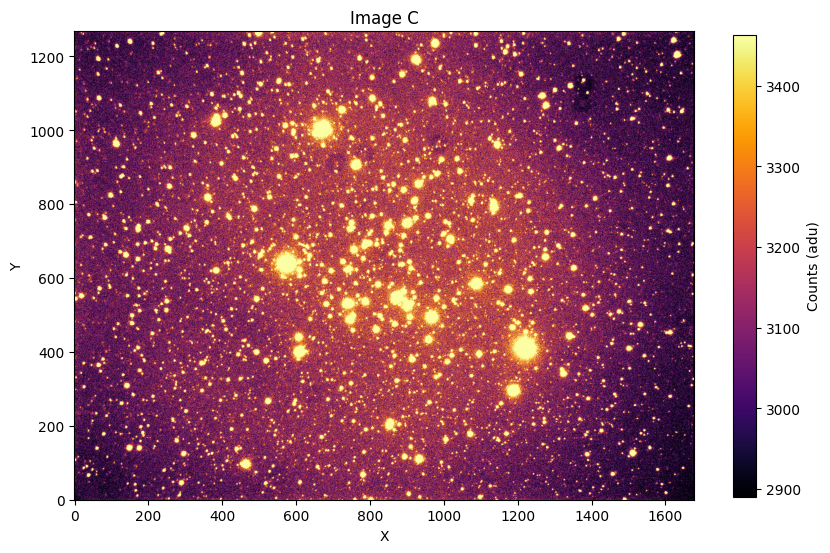

In [21]:
image = simple_fits_imshow("C.fits", title="Image C")

<font color=green>It's clear from this image that the flats have not been corrected. We can see some obvious visual artifacts, including the very clear dark donuts that have appeared (from unfocused particles either on the lens or between the object) as well as a strong vignette effect on the edges of the image. We are told that only one step was missed, so I can conclude that the flats were not corrected for.

## Question 2d (4 marks)

Inspect image D and in no more than 4 sentences describe which step of the image processing has been missed. Justify your answer using at least 2 pieces of evidence, which could include details of the image appearance and/or pixel values. 


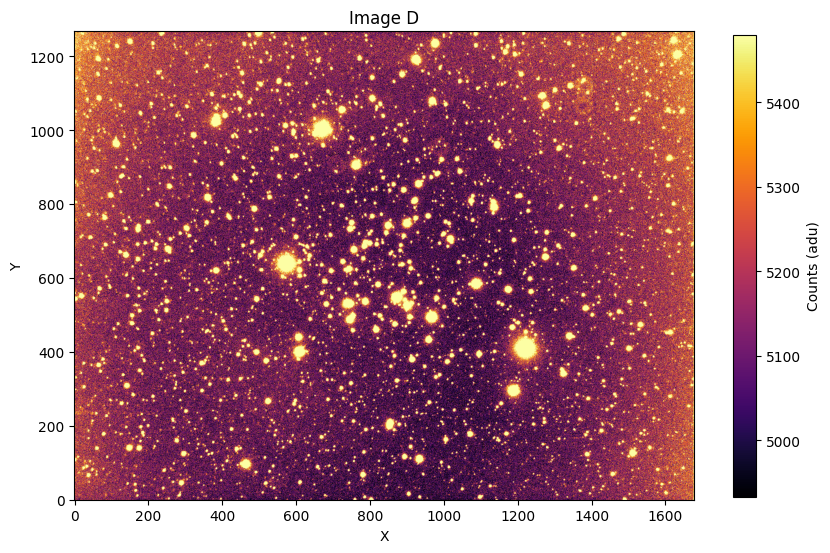

In [22]:
image = simple_fits_imshow("D.fits", title="Image D")

<font color=green>In this image the bias has not been subtracted. We can tell by the very strong light vignette effect on the sides of the image. We don't see any other telltale visual artifacts such as hot pixels or dark donuts that would indicate either the dark or the flat not being corrected for. So I can conclude the bias was not subtracted from this image.

# Noise and Gain

A common method of measuring the gain of a CCD is to use processed flat field images. If the pixel-to-pixel variations are dominated by photon shot noise then:

\begin{equation}
\mu_{photons} = \sigma_{photons}^2
\end {equation}

where $\mu_{photons}$ and $\sigma_{photons}$ are the mean and standard deviation in photons. We can convert this equation to ADU (counts) by putting in the gain, $g$, in electrons per ADU:

\begin{equation}
g \times \mu_{ADU} = g^2 \times \sigma_{ADU}^2
\end {equation}

# Question 3a (9 marks)

We have a raw flat field image, Flat_V_0.900secs_00011010.fit. Please process it using the calibration images provided.

CCDData([[3680.9805 , 3796.931  , 3846.96175, ..., 3423.98875,
          3331.92725, 3479.003  ],
         [3667.97   , 3727.98725, 3842.91675, ..., 3444.94   ,
          3388.00375, 3326.967  ],
         [3807.96625, 3918.946  , 3625.0195 , ..., 3520.01275,
          3423.99775, 3739.003  ],
         ...,
         [3543.95875, 3652.9745 , 3646.952  , ..., 3256.99025,
          3301.93775, 3312.94375],
         [3331.9535 , 3139.95425, 3041.97675, ..., 3296.95125,
          3167.93625, 3469.952  ],
         [3245.97825, 3310.9565 , 3315.9445 , ..., 3238.9415 ,
          3276.98575, 3373.961  ]], shape=(2536, 3358), unit='adu')

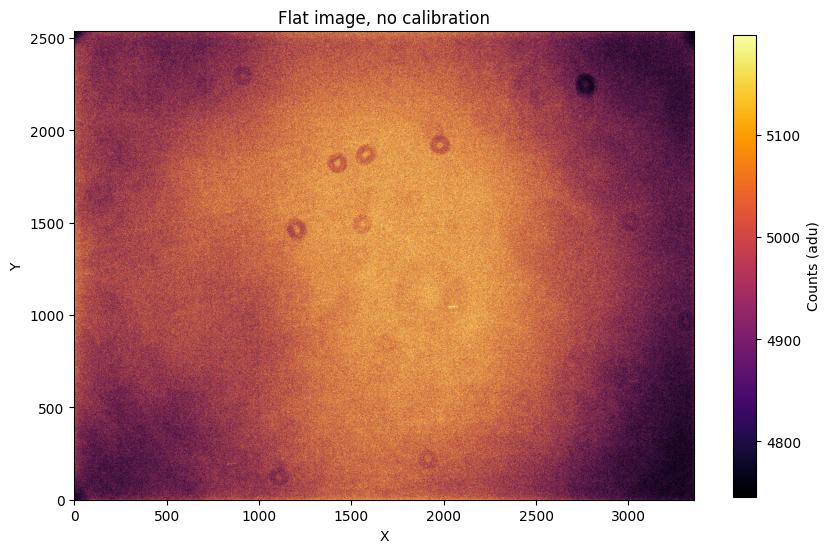

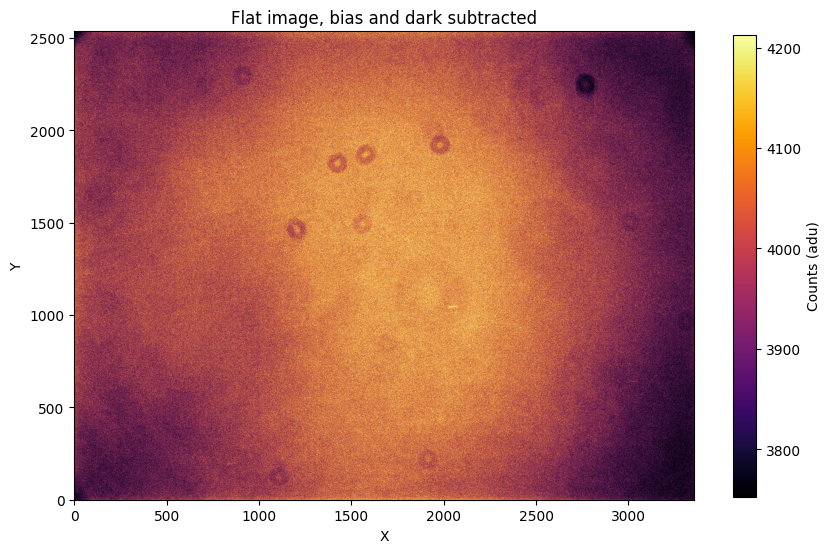

In [23]:
bias_image = CCDData.read("bias_median.fits", unit="adu")
dark_image = CCDData.read("dark_median.fits", unit="adu")
flat_image = CCDData.read("Flat_V_0.900secs_00011010.fit", unit="adu")

simple_fits_imshow(flat_image, title="Flat image, no calibration")

flat_image = ccdproc.subtract_bias(flat_image, bias_image)
flat_image = ccdproc.subtract_dark(flat_image, dark_image, exposure_time = 'EXPTIME', exposure_unit=u.second, scale=True)

simple_fits_imshow(flat_image, title="Flat image, bias and dark subtracted")


## Question 3b (4 marks)

If the gain is on the order of 1, approximately what would the random noise be in this image (in counts)?

In [44]:
gain = 1 # Given

# Fetch the mean, needed for the calculation
mean = np.mean(flat_image.data)
print(f"Mean  = {round(mean, 2)} adu")

# Random noise - see below justification
noise = np.sqrt(mean / gain)
print(f"Noise = {round(noise, 2)} counts")

Mean  = 3986.06 adu
Noise = 63.14 counts


<font color=green>We start with $$g\cdot\mu_\text{ADU}=g^2\cdot\sigma^2_\text{ADU},$$ which simplifies to $$g=\frac{\mu_\text{ADU}}{\sigma^2_\text{ADU}}.$$ The random noise is represented by $\sigma_\text{ADU}$, so $$\sigma_\text{ADU}=\sqrt{\frac{\mu_\text{ADU}}{g}}.$$ Given a mean of 3986.06, and a gain of 1, the random noise is 63.14 counts.

## Question 3c (4 marks)

What is the standard deviation of the whole image, and what is the likely cause of the measured standard deviation?

In [47]:
print(f"Standard deviation: {round(np.std(flat_image.data), 2)} counts")

Standard deviation: 140.69 counts


<font color=green>The standard deviation is actually higher than the random noise calculated above, assuming gain on the order of 1. This tells us one of two things.

* The gain is actually much less than 1, or

* The image is not dominated by shot noise

In our case it is likely a mix of both. Our measured standard deviation would be a result of lower gain as well as 'fixed pattern noise' arising from our vignette effect and the dust donuts (increasing spread of values)

## Question 3d (6 marks)

Determine the standard deviation for a subregion without obvious feature (like dust doughnuts). What is the standard deviation and its likely cause?

Standard deviation of subregion: 113.51 counts.


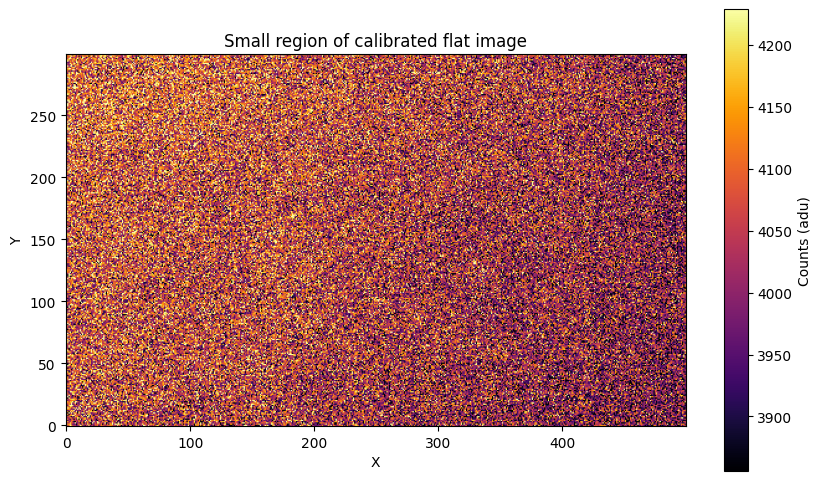

In [50]:
flat_image_subregion = flat_image.data[400:700, 2100:2600]
simple_fits_imshow(flat_image_subregion, title="Small region of calibrated flat image")

print(f"Standard deviation of subregion: {round(np.std(flat_image_subregion), 2)} counts.")

<font color=green>The likely cause here is the intrinsic pixel-to-pixel variation in sensitivity. <font color=red>**TODO**

## Question 3e

Determine the gain using the flat field and the measurements you have made of its properties.

<font color=red>**TODO**

# Galaxy photometry 

The Sloan Digital Sky Survey was a benchmark imaging and spectroscopic survey of a quarter of the entire sky. The SDSS images are freely available online and an example - frame-g-003063-3-0047.fits.bz2 - is provided with this notebook. This g-band image shows three galaxies that are part of the Virgo galaxy cluster.

For the following questions you will measure photometry for a galaxy which is assigned based on your student number:

If your student number ends in 0, 1 or 2 use NGC 4440 (x=1117, y=1316)

If your student number ends in 3, 4, 5 or 6 use NGC 4436 (x=1317, y=858)

if your student number ends if 7, 8 or 9 use NGC 4431 (x=1082, y=340)

We can open this image with fits.open without uncompressing it first.


In [26]:
image = fits.open('frame-g-003063-3-0047.fits.bz2')

<font color=green>My student number ends in 5, so I will use NGC 4436.

# Question 4a - 2 marks

What type of data is image? For example, is it a 2d array of pixel values, a list or something else?

In [27]:
print(image)
print(image[0].data)

[<astropy.io.fits.hdu.image.PrimaryHDU object at 0x000001A363B833D0>, <astropy.io.fits.hdu.image.ImageHDU object at 0x000001A36D921790>, <astropy.io.fits.hdu.table.BinTableHDU object at 0x000001A36D8E3E90>, <astropy.io.fits.hdu.table.BinTableHDU object at 0x000001A363BC9950>]
[[-0.00231552 -0.01828003  0.01364136 ...  0.00579834  0.00184631
   0.02954102]
 [-0.00231171  0.04156494  0.00964355 ...  0.01766968 -0.00605774
   0.01371765]
 [-0.02224731  0.01364136  0.00965881 ...  0.01371765 -0.00209808
  -0.01396179]
 ...
 [-0.00878906  0.01515198  0.00318527 ...  0.0151825   0.0151825
   0.03894043]
 [ 0.02313232 -0.0087738   0.01913452 ...  0.00727844  0.01913452
   0.01519775]
 [ 0.0031929   0.01116943 -0.0087738  ... -0.00062561  0.00333023
   0.06262207]]


<font color=green>The data type of image is called an HDUList, which is a list-like collection of header data units, the highest level format of a FITS file. To access the actual 2D array of pixel values, we'd need to call the first entry of this header list (image[0]), which will consist of a header and the data, and then specify that we want the data with image[0].data.

# Question 4b - 4 marks

Display the image with a suitable scaling that shows the random background noise.

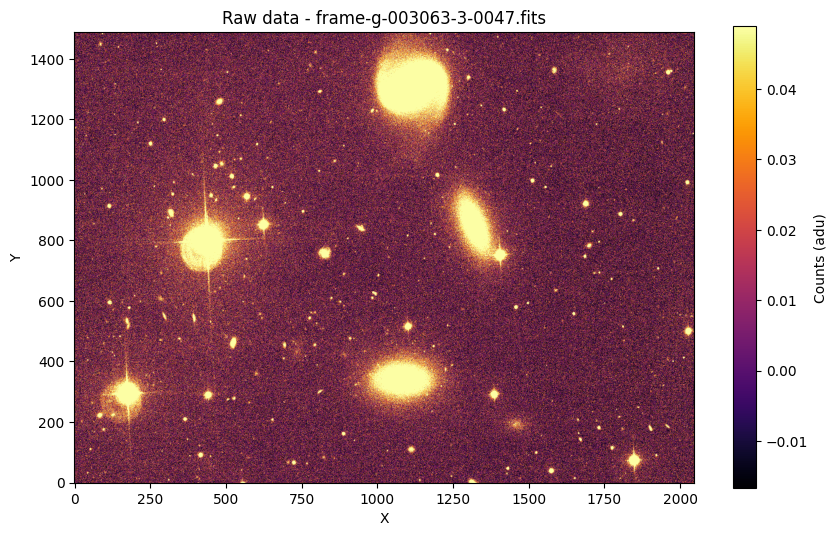

In [28]:
# Use percentiles to omit the data extremes
vmin = np.percentile(image[0].data, 15)
vmax = np.percentile(image[0].data, 95)

fig, ax = plt.subplots(1, 1, figsize=(10, 10))

# Labels
ax.set_xlabel("X")
ax.set_ylabel("Y")
ax.set_title("Raw data - frame-g-003063-3-0047.fits")

# Use inferno colouring. inverting the y-axis to make the origin (0,0)
plot = ax.imshow(image[0].data, cmap="inferno", vmin=vmin, vmax=vmax, origin="lower")
fig.colorbar(plot, shrink=0.6, label="Counts (adu)")

# Question 4c - 11 marks

The SDSS images are normalised so the magnitudes are given by 

\begin{equation}
m = 22.5 - 2.5 \times {\rm log} (f_{counts}).
\end{equation}

For the galaxy you have been assigned above measure the centroid and a 30 pixel radius aperture magnitude.

(You may want to compare with this literature values and consider whether you expect this magnitude to be brighter or fainter than the literature.)

In [53]:
point = (1317, 858)
aperture = CircularAperture(point, r=30)
phot_table = aperture_photometry(image[0].data, aperture)

magnitude = 22.5 - 2.5 * np.log10(phot_table[0]['aperture_sum'])

print(f"G-band Magnitude: {round(magnitude, 2)}")

G-band Magnitude: 14.67


<font color=green>According to the official SDSS catalogue, the listed G-band magnitude as calculated by the 'Model' method is 14.011, slightly brighter than what I obtained. The most likely cause of this is due to the fact that my galaxy is not perfectly circular on the CCD. An elliptical aperture would be much more appropriate here. By using a circular aperture I am underestimating the flux, resulting in a fainter (higher) magnitude.

See https://ned.ipac.caltech.edu/byname?objname=ngc+4436&hconst=67.8&omegam=0.308&omegav=0.692&wmap=4&corr_z=1

# Question 4d - 13 marks

An elliptical aperture can produce more accurate galaxy photometry than a circular aperture. Define a suitable elliptical aperture for your galaxy, and measure the magnitude.
    
Hint: You may want to overplot the ellipse on the image by adapting the code below.

In [62]:
# Estimated ellipse properties found by examining with ds9, in pixels
point = (1317, 858)
semimajor_axis = 87
semiminor_axis = 36
theta = 110 # degrees

aperture = EllipticalAperture(point, semimajor_axis, semiminor_axis, theta*u.degree)
phot_table = aperture_photometry(image[0].data, aperture)

magnitude = 22.5 - 2.5 * np.log10(phot_table[0]['aperture_sum'])
print(f"Elliptical G-band Magnitude: {round(magnitude, 2)}")

Elliptical G-band Magnitude: 14.11


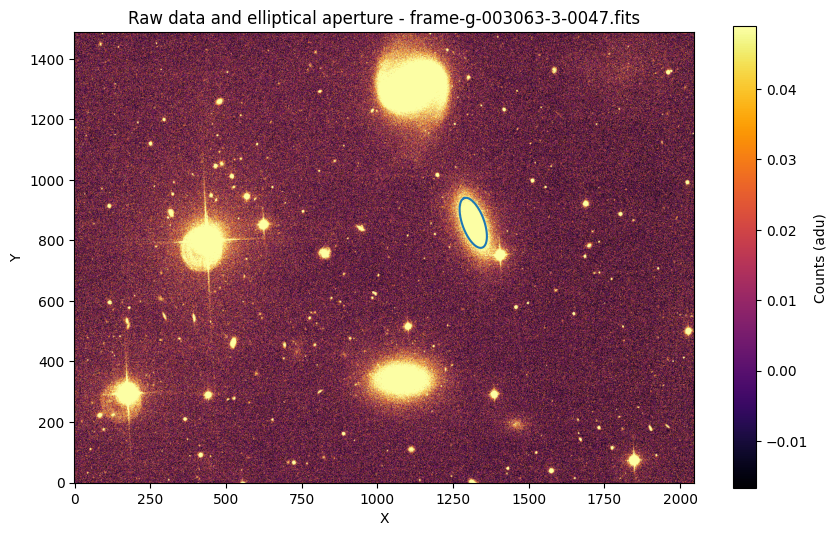

In [63]:
# Ellipse plotter

x = point[0]
y = point[1]
ia = semimajor_axis
ib = semiminor_axis
theta = 110 * np.pi / 180

# Loop to obtain ellipse points
px=[]
py=[]
t=0.0
while t<2.01*np.pi:
    px.append(x + ia*np.cos(t)*np.cos(theta) - ib*np.sin(t)*np.sin(theta))
    py.append(y + ia*np.cos(t)*np.sin(theta) + ib*np.sin(t)*np.cos(theta))
    t=t+0.05

# -- PLOT ELLIPSE OVER ORIGINAL IMAGE --

# Use percentiles to omit the data extremes
vmin = np.percentile(image[0].data, 15)
vmax = np.percentile(image[0].data, 95)

fig, ax = plt.subplots(1, 1, figsize=(10, 10))

# Labels
ax.set_xlabel("X")
ax.set_ylabel("Y")
ax.set_title("Raw data and elliptical aperture - frame-g-003063-3-0047.fits")

# Use inferno colouring. inverting the y-axis to make the origin (0,0)
plot = ax.imshow(image[0].data, cmap="inferno", vmin=vmin, vmax=vmax, origin="lower")
ax.plot(px, py)
fig.colorbar(plot, shrink=0.6, label="Counts (adu)")

<font color=green>My elliptical flux is 14.11, much closer to the [literature value](https://ned.ipac.caltech.edu/byname?objname=ngc+4436&hconst=67.8&omegam=0.308&omegav=0.692&wmap=4&corr_z=1) of 14.011. This makes sense since an elliptical aperture is much more appropriate here. The reality is that the SDSS magnitude is calculated using a much more complex algorithm involving fitting both an elliptical and an exponential profile and using whichever is a better fit. The literature also lists a 'CModel' algorithm which results in a magnitude of 13.886, obtained by combining both the elliptical and exponential fits and scaling them. I felt that my chosen values for the aperture were appropriate given the information I had access to for this assignment, and I would conclude that my results agree with the literature.

## Exercise (not marked)

One way to determine the ideal aperture size is to use a series of apertures and find the asymptotic magnitude. There will be a sweet spot where the magnitude is stable (or close to it) as a function of aperture size before random noise and source confusion cause the magnitude to start a random walk. You could try implementing this for your galaxy to see this in action.